# Perceptron & Single-Layer Perceptron (SLP)


## Theory

### Perceptron (step activation)
The classic perceptron model makes predictions with a hard threshold:

$$\hat y = \mathrm{sign}(w^T x + b)\in\{\pm1\}$$

and updates its weights only when it misclassifies an example.  For a sample
$(x,y)$ with $y\in\{\pm1\}$ and learning rate $\eta$, the update rule is

$$w \leftarrow w + \eta (y - \hat y) x,
    \qquad b \leftarrow b + \eta (y - \hat y).$$

Because $(y-\hat y)$ is zero when the example is correctly classified with a
margin of at least 1, only mistakes trigger changes.  The perceptron convergence
theorem guarantees that if the training data are linearly separable the algorithm
will find a separating hyperplane in a finite number of updates.

### Single-Layer Perceptron (logistic/SLP)
Replacing the step with a sigmoid activation turns the model into a logistic
regression network.  The decision function becomes

$$z = w^T x + b,\qquad p = \sigma(z) = \frac{1}{1+e^{-z}}$$

and we optimize the binary cross‑entropy (logistic) loss over $n$ samples:

$$L(w,b)= -\frac{1}{n}\sum_{i=1}^n\big[y_i\log p_i + (1-y_i)\log(1-p_i)\big],
    \qquad p_i=\sigma(w^T x_i+b).$$

The gradients for one example are

$$\frac{\partial L}{\partial w} = (p - y)x,
    \qquad \frac{\partial L}{\partial b} = p - y,$$

so the stochastic gradient descent update is

$$w\leftarrow w - \eta (p - y)x,\qquad b\leftarrow b - \eta (p - y).$$

We will implement both the original hard‑threshold perceptron and the sigmoid
SLP, track epoch‑wise accuracy and loss, and compare against
`sklearn.linear_model.Perceptron` which uses the first variant.

## 1. Imports, Setup & Shared Utilities

In [1]:
import os, json, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, accuracy_score)
from sklearn.linear_model import Perceptron

BASE_DIR = r"D:\Repo\cryptoflow"

print("os.chdir =", os.getcwd())
print("BASE_DIR =", BASE_DIR)
TRAIN_FILE    = os.path.join(BASE_DIR, 'data', 'final_training_data_classification_train.csv')
TEST_FILE     = os.path.join(BASE_DIR, 'data', 'final_training_data_classification_test.csv')
FEATURES_FILE = os.path.join(BASE_DIR, 'data', 'selected_features_classification.json')
SCALER_FILE   = os.path.join(BASE_DIR, 'models', 'scaler_classification.pkl')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
RESULTS_DIR   = os.path.join(BASE_DIR, 'results')
PLOTS_DIR     = os.path.join(BASE_DIR, 'plots')
RESULTS_CSV   = os.path.join(RESULTS_DIR, 'classification_results.csv')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# utilities

def compute_metrics(model_name, y_true, y_pred, y_prob=None):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = 2*precision*sensitivity/(precision+sensitivity) if (precision+sensitivity) > 0 else 0.0
    auc         = roc_auc_score(y_true, y_prob) if y_prob is not None else float('nan')
    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(f"  Confusion Matrix : TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"  Accuracy         : {accuracy:.4f}")
    print(f"  Precision        : {precision:.4f}")
    print(f"  Sensitivity      : {sensitivity:.4f}")
    print(f"  Specificity(TNR) : {specificity:.4f}")
    print(f"  F1-Score         : {f1:.4f}")
    print(f"  ROC-AUC          : {auc:.4f}")
    print(f"{'='*55}")
    return {'model': model_name, 'accuracy': round(accuracy,4), 'precision': round(precision,4),
            'sensitivity': round(sensitivity,4), 'specificity': round(specificity,4),
            'tnr': round(specificity,4), 'f1': round(f1,4),
            'roc_auc': round(auc,4) if not np.isnan(auc) else None,
            'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn)}


def save_results(metrics_dict):
    row = pd.DataFrame([metrics_dict])
    if os.path.exists(RESULTS_CSV):
        existing = pd.read_csv(RESULTS_CSV)
        existing = existing[existing['model'] != metrics_dict['model']]
        row = pd.concat([existing, row], ignore_index=True)
    row.to_csv(RESULTS_CSV, index=False)
    print(f"Results saved to {RESULTS_CSV}")


def plot_confusion_matrix(y_true, y_pred, model_name, save_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Down (0)','Up (1)'], yticklabels=['Down (0)','Up (1)'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

print("Utilities loaded.")

os.chdir = d:\Repo\cryptoflow\Notebooks
BASE_DIR = D:\Repo\cryptoflow
Utilities loaded.


## 2. Load & Scale Data

In [2]:
with open(FEATURES_FILE) as f:
    features = json.load(f)

with open(SCALER_FILE, 'rb') as f:
    scaler = pickle.load(f)

train_df = pd.read_csv(TRAIN_FILE)
test_df  = pd.read_csv(TEST_FILE)

X_train = scaler.transform(train_df[features].values)
y_train = train_df['target_class'].values
X_test  = scaler.transform(test_df[features].values)
y_test  = test_df['target_class'].values

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Features: {features}")

X_train: (60260, 10)  |  X_test: (10635, 10)
Features: ['close_position', 'return_lag_1h', 'log_return_1h', 'gk_avg_3h', 'log_return_3h', 'gk_lag_1h', 'hl_range_pct', 'trade_intensity', 'atr_lag_3h', 'log_return_6h']


d:\Repo\cryptoflow\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Repo\cryptoflow\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 3. Scratch Perceptron & SLP Training


Epoch 0: errors=30197, acc=0.5305
Epoch 1: errors=30160, acc=0.5322
Epoch 2: errors=30095, acc=0.5282
Epoch 3: errors=30110, acc=0.5275
Epoch 4: errors=30160, acc=0.5317
Epoch 5: errors=30119, acc=0.5305
Epoch 6: errors=30130, acc=0.5421
Epoch 7: errors=29917, acc=0.5268
Epoch 8: errors=30199, acc=0.5314
Epoch 9: errors=30173, acc=0.5299
Epoch 10: errors=30147, acc=0.5315
Epoch 11: errors=30055, acc=0.5362
Epoch 12: errors=30113, acc=0.5310
Epoch 13: errors=30176, acc=0.5256
Epoch 14: errors=30174, acc=0.5210
Epoch 15: errors=30089, acc=0.5430
Epoch 16: errors=29949, acc=0.5337
Epoch 17: errors=30039, acc=0.5291
Epoch 18: errors=30238, acc=0.5408
Epoch 19: errors=30146, acc=0.5385
Epoch 0: loss=0.6931, acc=0.5093
Epoch 1: loss=0.6931, acc=0.5475
Epoch 2: loss=0.6931, acc=0.5475
Epoch 3: loss=0.6930, acc=0.5474
Epoch 4: loss=0.6930, acc=0.5474
Epoch 5: loss=0.6930, acc=0.5474
Epoch 6: loss=0.6929, acc=0.5474
Epoch 7: loss=0.6929, acc=0.5474
Epoch 8: loss=0.6928, acc=0.5474
Epoch 9: loss

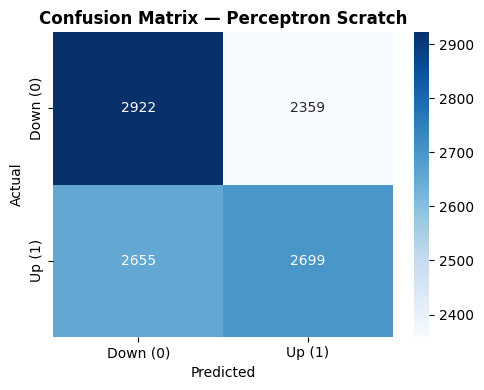

Saved: D:\Repo\cryptoflow\plots\confusion_perceptron_scratch.png

  SLP Scratch
  Confusion Matrix : TN=2725  FP=2556  FN=2522  TP=2832
  Accuracy         : 0.5225
  Precision        : 0.5256
  Sensitivity      : 0.5290
  Specificity(TNR) : 0.5160
  F1-Score         : 0.5273
  ROC-AUC          : nan
Results saved to D:\Repo\cryptoflow\results\classification_results.csv


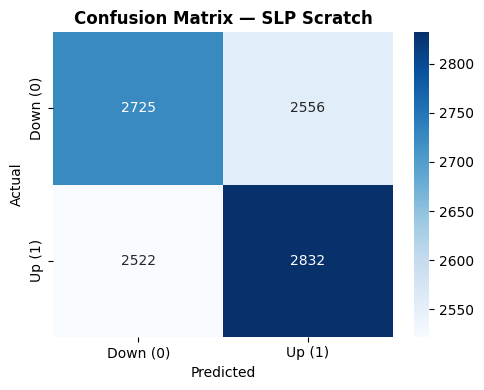

Saved: D:\Repo\cryptoflow\plots\confusion_slp_scratch.png


In [3]:
# basic perceptron with step activation
def perceptron_train(X, y, lr=0.01, n_epochs=10):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0
    for epoch in range(n_epochs):
        errors = 0
        for xi, yi in zip(X, y):
            pred = 1 if np.dot(w, xi) + b >= 0 else 0
            update = lr * (yi - pred)
            if update != 0:
                w += update * xi
                b += update
                errors += 1
        acc = (y == (np.dot(X, w) + b >= 0)).mean()
        print(f"Epoch {epoch}: errors={errors}, acc={acc:.4f}")
    return w, b

# single-layer perceptron (sigmoid) with BCE loss
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def slp_train(X, y, lr=0.01, n_epochs=10):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0
    for epoch in range(n_epochs):
        z = np.dot(X, w) + b
        preds = sigmoid(z)
        loss = -np.mean(y * np.log(preds + 1e-8) + (1-y)*np.log(1-preds+1e-8))
        grad_w = np.dot(X.T, (preds - y)) / n_samples
        grad_b = np.mean(preds - y)
        w -= lr * grad_w
        b -= lr * grad_b
        acc = ((preds >= 0.5) == y).mean()
        print(f"Epoch {epoch}: loss={loss:.4f}, acc={acc:.4f}")
    return w, b

# train both models
w_p, b_p = perceptron_train(X_train, y_train, lr=0.001, n_epochs=20)
w_s, b_s = slp_train(X_train, y_train, lr=0.01, n_epochs=20)

# evaluate on test set
pred_test_p = (np.dot(X_test, w_p) + b_p >= 0).astype(int)
pred_test_s = (sigmoid(np.dot(X_test, w_s) + b_s) >= 0.5).astype(int)

metrics_p = compute_metrics('Perceptron Scratch', y_test, pred_test_p)
save_results(metrics_p)
plot_confusion_matrix(y_test, pred_test_p, 'Perceptron Scratch', os.path.join(PLOTS_DIR, 'confusion_perceptron_scratch.png'))

metrics_s = compute_metrics('SLP Scratch', y_test, pred_test_s)
save_results(metrics_s)
plot_confusion_matrix(y_test, pred_test_s, 'SLP Scratch', os.path.join(PLOTS_DIR, 'confusion_slp_scratch.png'))


## 4. sklearn Perceptron


  Perceptron sklearn
  Confusion Matrix : TN=1015  FP=4266  FN=1028  TP=4326
  Accuracy         : 0.5022
  Precision        : 0.5035
  Sensitivity      : 0.8080
  Specificity(TNR) : 0.1922
  F1-Score         : 0.6204
  ROC-AUC          : nan
Results saved to D:\Repo\cryptoflow\results\classification_results.csv


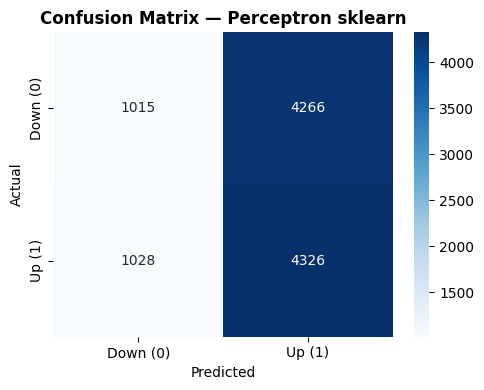

Saved: D:\Repo\cryptoflow\plots\confusion_perceptron_sklearn.png
sklearn perceptron done


In [4]:
sk_p = Perceptron(max_iter=1000, tol=1e-3, random_state=42)
sk_p.fit(X_train, y_train)
y_pred_sk = sk_p.predict(X_test)

metrics_sk = compute_metrics('Perceptron sklearn', y_test, y_pred_sk)
save_results(metrics_sk)
plot_confusion_matrix(y_test, y_pred_sk, 'Perceptron sklearn', os.path.join(PLOTS_DIR, 'confusion_perceptron_sklearn.png'))

print('sklearn perceptron done')

## 5. sklearn Logistic Regression (SLP)


In [ ]:
from sklearn.linear_model import LogisticRegression
log = LogisticRegression(max_iter=1000, solver='lbfgs')
log.fit(X_train, y_train)
y_pred_log = log.predict(X_test)
y_prob_log = log.predict_proba(X_test)[:,1]
metrics_log = compute_metrics('Logistic sklearn', y_test, y_pred_log, y_prob_log)
save_results(metrics_log)
plot_confusion_matrix(y_test, y_pred_log, 'Logistic sklearn', os.path.join(PLOTS_DIR, 'confusion_logistic_sklearn.png'))
print('sklearn logistic done')
